# Business Problem:
Atletico Madrid are losing Antoine Griezmann arguably their best player for the last decade - at the end of the current 2025/26 seasin. Beyond an emotional void, his departure causes disrupt in the current Atletico Madrid playing structure. Aside from goal scoring, Griezmann's second phase at the club saw him have a sligtly different rolecon its due to age or player ; 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Test that everything loaded
print("All good, ready to pull data")

All good, ready to pull data


In [5]:
# Load Data
df = pd.read_csv("players_data-2025_2026.csv")
print(df.shape)
print(df.columns.tolist())

(2731, 102)
['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'G+A-PK', 'Rk_stats_keeper', 'Nation_stats_keeper', 'Pos_stats_keeper', 'Comp_stats_keeper', 'Age_stats_keeper', 'Born_stats_keeper', 'MP_stats_keeper', 'Starts_stats_keeper', 'Min_stats_keeper', '90s_stats_keeper', 'GA', 'GA90', 'SoTA', 'Saves', 'Save%', 'W', 'D', 'L', 'CS', 'CS%', 'PKatt_stats_keeper', 'PKA', 'PKsv', 'PKm', 'Rk_stats_shooting', 'Nation_stats_shooting', 'Pos_stats_shooting', 'Comp_stats_shooting', 'Age_stats_shooting', 'Born_stats_shooting', '90s_stats_shooting', 'Gls_stats_shooting', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'PK_stats_shooting', 'PKatt_stats_shooting', 'Rk_stats_playing_time', 'Nation_stats_playing_time', 'Pos_stats_playing_time', 'Comp_stats_playing_time', 'Age_stats_playing_time', 'Born_stats_playing_time', 'MP_stats_playing_time', 'Min_stats_playing_time', 'Mn/MP', 'M

In [16]:
# Filter for Griezmann
cols = ['Player', 'Squad', 'Comp', 'Pos', 'Age', 'Min', '90s',
        'Gls', 'Ast', 'G+A', 'G-PK', 'Sh', 'SoT', 'SoT%',
        'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'Int', 'TklW', 
        'Fld', 'Crs']

df_clean = df[cols].copy()

griez = df_clean[df_clean['Player'].str.contains('Griezmann', case=False, na=False)]
print(griez.to_string())

                 Player            Squad        Comp Pos   Age   Min   90s  Gls  Ast  G+A  G-PK  Sh  SoT  SoT%  Sh/90  SoT/90  G/Sh  G/SoT  Int  TklW  Fld  Crs
1007  Antoine Griezmann  Atlético Madrid  es La Liga  FW  35.0  1042  11.6    6    1    7     6  36   19  52.8   3.11    1.64  0.17   0.32    3     7    6   52


In [24]:
# Per90 Griezmann Stats
griez_statsPer90 = griez.copy()

numeric_cols = ['Gls', 'Ast', 'G+A', 'G-PK', 'Sh', 'SoT', 'SoT%',
                'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'Int', 'TklW', 'Fld', 'Crs']

griez_statsPer90[numeric_cols] = griez_statsPer90[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Per90 stats
griez_statsPer90['Gls/90'] = griez_statsPer90['Gls'] / griez_statsPer90['90s']
griez_statsPer90['Ast/90'] = griez_statsPer90['Ast'] / griez_statsPer90['90s']
griez_statsPer90['Int/90'] = griez_statsPer90['Int'] / griez_statsPer90['90s']
griez_statsPer90['TklW/90'] = griez_statsPer90['TklW'] / griez_statsPer90['90s']
griez_statsPer90['Fld/90'] = griez_statsPer90['Fld'] / griez_statsPer90['90s']
griez_statsPer90['Crs/90'] = griez_statsPer90['Crs'] / griez_statsPer90['90s']


# Griezmann 2025-2026 Per90 Stats Profile

print("Griezmann 2025-2026 Per90 Stats Profile:\n")
print(f"Squad: {griez_statsPer90['Squad'].values[0]}")
print(f"Age: {griez_statsPer90['Age'].values[0]}")
print(f"Minutes: {griez_statsPer90['Min'].values[0]}")
print(f"90s played: {griez_statsPer90['90s'].values[0]}")
print(f"SoT%: {griez_statsPer90['SoT%'].values[0]:.2f}")
print()
print("Attacking Threat:\n")
print(f"Goals/90: {griez_statsPer90['Gls/90'].values[0]:.2f}")
print(f"Shots/90: {griez_statsPer90['Sh/90'].values[0]:.2f}")
print(f"SoT/90: {griez_statsPer90['SoT/90'].values[0]:.2f}")
print(f"G/Sh: {griez_statsPer90['G/Sh'].values[0]:.2f}")
print(f"G/SoT: {griez_statsPer90['G/SoT'].values[0]:.2f}")
print()
print("Creative Play:\n")
print(f"Ast/90: {griez_statsPer90['Ast/90'].values[0]:.2f}")
print(f"Crs/90: {griez_statsPer90['Crs/90'].values[0]:.2f}")
print(f"Fld/90: {griez_statsPer90['Fld/90'].values[0]:.2f}")
print()
print("Defensive Contributions:\n")
print(f"Int/90: {griez_statsPer90['Int/90'].values[0]:.2f}")
print(f"TklW/90: {griez_statsPer90['TklW/90'].values[0]:.2f}")


Griezmann 2025-2026 Per90 Stats Profile:

Squad: Atlético Madrid
Age: 35.0
Minutes: 1042
90s played: 11.6
SoT%: 52.80

Attacking Threat:

Goals/90: 0.52
Shots/90: 3.11
SoT/90: 1.64
G/Sh: 0.17
G/SoT: 0.32

Creative Play:

Ast/90: 0.09
Crs/90: 4.48
Fld/90: 0.52

Defensive Contributions:

Int/90: 0.26
TklW/90: 0.60


In [27]:
# Filter Candidate pool for profiling
candidates = df_clean[
    (df_clean['Min'] >= 900) &
    (df_clean['Age'] <= 30) &
    (df_clean['Pos'].str.contains('FW|MF', case=False, na=False)) &
    (~df_clean['Player'].str.contains('Griezmann', case=False, na=False))
].copy()

print(f"Candidate pool: {candidates.shape[0]} players")

Candidate pool: 753 players


In [ ]:
# Per90 stats for candidates
numeric_cols = ['Gls', 'Ast', 'G+A', 'G-PK', 'Sh', 'SoT', 'SoT%',
                'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'Int', 'TklW', 'Fld', 'Crs']

candidates[numeric_cols] = candidates[numeric_cols].apply(pd.to_numeric, errors='coerce')

candidates['Gls/90'] = candidates['Gls'] / candidates['90s']
candidates['Ast/90'] = candidates['Ast'] / candidates['90s']
candidates['Int/90'] = candidates['Int'] / candidates['90s']
candidates['TklW/90'] = candidates['TklW'] / candidates['90s']
candidates['Fld/90'] = candidates['Fld'] / candidates['90s']
candidates['Crs/90'] = candidates['Crs'] / candidates['90s']

candidates_Per90 = candidates[['Player', 'Squad', 'Comp', 'Pos', 'Age', 'Min',
                              'Gls/90', 'Ast/90', 'Sh/90', 'SoT/90', 
                              'G/Sh', 'G/SoT', 'SoT%',
                              'Int/90', 'TklW/90', 'Fld/90', 'Crs/90']].copy()

candidates_Per90 = candidates_Per90.dropna()

print(f"Clean candidate pool: {candidates_Per90.shape[0]} players")

Clean candidate pool: 737 players


In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

features = ['Gls/90', 'Ast/90', 'Sh/90', 'SoT/90', 
            'G/Sh', 'G/SoT', 'SoT%',
            'Int/90', 'TklW/90', 'Fld/90', 'Crs/90']

# Scale features to same scale
scaler = StandardScaler()
candidates_scaled = scaler.fit_transform(candidates_Per90[features])

# Scale Griezmann using the same scaler
griez_features = griez_statsPer90[features].apply(pd.to_numeric, errors='coerce')
griez_scaled = scaler.transform(griez_features)

# Cosine similarity measure to find players with similar profiles relative to Griezmann.
# A score of 1 means identical profiles, while a score closer to 0 indicates less similarity.
similarities = cosine_similarity(griez_scaled, candidates_scaled)[0]


candidates_Per90 = candidates_Per90.copy()
candidates_Per90['similarity'] = similarities

results = candidates_Per90.sort_values('similarity', ascending=False).head(15)

print(results[['Player', 'Squad', 'Comp', 'Age', 'Min', 'similarity']].to_string())

                 Player                Squad                Comp   Age   Min  similarity
1311      Ansgar Knauff  Eintracht Frankfurt       de Bundesliga  24.0  1072    0.960746
1634       Bryan Mbeumo       Manchester Utd  eng Premier League  26.0  2187    0.951508
91       Julián Álvarez      Atlético Madrid          es La Liga  26.0  1895    0.916160
994        Amine Gouiri            Marseille          fr Ligue 1  26.0   973    0.890991
2023     Rayan Philippe         Hamburger SV       de Bundesliga  25.0  1135    0.886118
2323     Benjamin Šeško       Manchester Utd  eng Premier League  22.0  1342    0.882791
1004    Mason Greenwood            Marseille          fr Ligue 1  24.0  1997    0.882595
2316    Antoine Semenyo          Bournemouth  eng Premier League  26.0  1798    0.878837
2067  Christian Pulisic                Milan          it Serie A  27.0  1306    0.876017
1534       Said El Mala                 Köln       de Bundesliga  19.0  1471    0.873176
216     Bradley Barco

## Pivot
Based on the pool candidates, players who are considered 9s are showing up and although have a very high similarity score - reliability gets questioned due to the varying styles of players.
For example Alexander Sorloth is not a similar player to Griezmann - suggesting the limited/managed minutes Griezmann has faced int he 25/26 season has led to a weird data.

24/25 Griezmann stats will be his new benchmark and will be used instead to profile against 25/26 candidates.

In [30]:
df_2425 = pd.read_csv("players_data-2024_2025.csv")
print(df_2425.shape)
print(df_2425.columns.tolist())

(2854, 267)
['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP', 'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt', 'CrdY', 'CrdR', 'xG', 'npxG', 'xAG', 'npxG+xAG', 'PrgC', 'PrgP', 'PrgR', 'G+A-PK', 'xG+xAG', 'Rk_stats_shooting', 'Nation_stats_shooting', 'Pos_stats_shooting', 'Comp_stats_shooting', 'Age_stats_shooting', 'Born_stats_shooting', '90s_stats_shooting', 'Gls_stats_shooting', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'Dist', 'FK', 'PK_stats_shooting', 'PKatt_stats_shooting', 'xG_stats_shooting', 'npxG_stats_shooting', 'npxG/Sh', 'G-xG', 'np:G-xG', 'Rk_stats_passing', 'Nation_stats_passing', 'Pos_stats_passing', 'Comp_stats_passing', 'Age_stats_passing', 'Born_stats_passing', '90s_stats_passing', 'Cmp', 'Att', 'Cmp%', 'TotDist', 'PrgDist', 'Ast_stats_passing', 'xAG_stats_passing', 'xA', 'A-xAG', 'KP', '1/3', 'PPA', 'CrsPA', 'PrgP_stats_passing', 'Rk_stats_passing_types', 'Nation_stats_passing_types', 'Pos_stats_passing_types',

In [32]:
griez_2425 = df_2425[df_2425['Player'].str.contains('Griezmann', case=False, na=False)]

cols_2425 = ['Player', 'Squad', 'Comp', 'Pos', 'Age', 'Min', '90s',
             'Gls', 'Ast', 'npxG', 'xAG', 'G-PK',
             'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT',
             'PrgP', 'PrgC', 'PrgR', 'KP', 'PPA', 'SCA', 'SCA90',
             'Tkl', 'TklW', 'Int', 'Att 3rd',
             'Fld', 'Crs', 'Carries', 'Rec']

griez_2425 = griez_2425[cols_2425].copy()
griez_2425[cols_2425[6:]] = griez_2425[cols_2425[6:]].apply(pd.to_numeric, errors='coerce')

print(griez_2425.to_string())

                 Player            Squad        Comp    Pos   Age   Min   90s  Gls  Ast  npxG  xAG  G-PK  Sh  SoT  SoT%  Sh/90  SoT/90  G/Sh  G/SoT  PrgP  PrgC  PrgR  KP  PPA  SCA  SCA90  Tkl  TklW  Int  Att 3rd  Fld  Crs  Carries   Rec
1063  Antoine Griezmann  Atlético Madrid  es La Liga  FW,MF  33.0  2469  27.4    8    7   5.9  7.1     7  48   17  35.4   1.75    0.62  0.15   0.41   143    46   177  48   47   93   3.39   30    17    6        4    2  138      969  1255


In [34]:
griez_per90_2425 = griez_2425.copy()

griez_per90_2425['Gls/90'] = griez_per90_2425['Gls'] / griez_per90_2425['90s']
griez_per90_2425['Ast/90'] = griez_per90_2425['Ast'] / griez_per90_2425['90s']
griez_per90_2425['npxG/90'] = griez_per90_2425['npxG'] / griez_per90_2425['90s']
griez_per90_2425['xAG/90'] = griez_per90_2425['xAG'] / griez_per90_2425['90s']
griez_per90_2425['PrgP/90'] = griez_per90_2425['PrgP'] / griez_per90_2425['90s']
griez_per90_2425['PrgC/90'] = griez_per90_2425['PrgC'] / griez_per90_2425['90s']
griez_per90_2425['PrgR/90'] = griez_per90_2425['PrgR'] / griez_per90_2425['90s']
griez_per90_2425['KP/90'] = griez_per90_2425['KP'] / griez_per90_2425['90s']
griez_per90_2425['PPA/90'] = griez_per90_2425['PPA'] / griez_per90_2425['90s']
griez_per90_2425['SCA/90'] = griez_per90_2425['SCA'] / griez_per90_2425['90s']
griez_per90_2425['TklW/90'] = griez_per90_2425['TklW'] / griez_per90_2425['90s']
griez_per90_2425['Int/90'] = griez_per90_2425['Int'] / griez_per90_2425['90s']
griez_per90_2425['Fld/90'] = griez_per90_2425['Fld'] / griez_per90_2425['90s']
griez_per90_2425['Crs/90'] = griez_per90_2425['Crs'] / griez_per90_2425['90s']
griez_per90_2425['Att3rd/90'] = griez_per90_2425['Att 3rd'] / griez_per90_2425['90s']

print("Griezmann 2024/25 Per90 Stats Profile\n")
print(f"Squad: {griez_per90_2425['Squad'].values[0]}")
print(f"Age: {griez_per90_2425['Age'].values[0]}")
print(f"Minutes: {griez_per90_2425['Min'].values[0]}")
print(f"90s played: {griez_per90_2425['90s'].values[0]}")
print()
print("Attacking Threat:\n")
print(f"Goals/90: {griez_per90_2425['Gls/90'].values[0]:.2f}")
print(f"npxG/90: {griez_per90_2425['npxG/90'].values[0]:.2f}")
print(f"Shots/90: {griez_per90_2425['Sh/90'].values[0]:.2f}")
print(f"SoT/90: {griez_per90_2425['SoT/90'].values[0]:.2f}")
print(f"G/Sh: {griez_per90_2425['G/Sh'].values[0]:.2f}")
print(f"G/SoT: {griez_per90_2425['G/SoT'].values[0]:.2f}")
print(f"SoT%: {griez_per90_2425['SoT%'].values[0]:.2f}")
print()
print("Creative Play:\n")
print(f"Ast/90: {griez_per90_2425['Ast/90'].values[0]:.2f}")
print(f"xAG/90: {griez_per90_2425['xAG/90'].values[0]:.2f}")
print(f"KP/90: {griez_per90_2425['KP/90'].values[0]:.2f}")
print(f"PPA/90: {griez_per90_2425['PPA/90'].values[0]:.2f}")
print(f"SCA/90: {griez_per90_2425['SCA/90'].values[0]:.2f}")
print(f"PrgP/90: {griez_per90_2425['PrgP/90'].values[0]:.2f}")
print(f"PrgC/90: {griez_per90_2425['PrgC/90'].values[0]:.2f}")
print(f"PrgR/90: {griez_per90_2425['PrgR/90'].values[0]:.2f}")
print(f"Crs/90: {griez_per90_2425['Crs/90'].values[0]:.2f}")
print()
print("Defensive Contributions:\n")
print(f"TklW/90: {griez_per90_2425['TklW/90'].values[0]:.2f}")
print(f"Int/90: {griez_per90_2425['Int/90'].values[0]:.2f}")
print(f"Fld/90: {griez_per90_2425['Fld/90'].values[0]:.2f}")
print(f"Att3rd/90: {griez_per90_2425['Att3rd/90'].values[0]:.2f}")

Griezmann 2024/25 Per90 Stats Profile

Squad: Atlético Madrid
Age: 33.0
Minutes: 2469
90s played: 27.4

Attacking Threat:

Goals/90: 0.29
npxG/90: 0.22
Shots/90: 1.75
SoT/90: 0.62
G/Sh: 0.15
G/SoT: 0.41
SoT%: 35.40

Creative Play:

Ast/90: 0.26
xAG/90: 0.26
KP/90: 1.75
PPA/90: 1.72
SCA/90: 3.39
PrgP/90: 5.22
PrgC/90: 1.68
PrgR/90: 6.46
Crs/90: 5.04

Defensive Contributions:

TklW/90: 0.62
Int/90: 0.22
Fld/90: 0.07
Att3rd/90: 0.15


In [52]:
shared_features = ['Gls/90', 'Ast/90', 'Sh/90', 'SoT/90',
                   'G/Sh', 'G/SoT', 'SoT%',
                   'Int/90', 'TklW/90', 'Fld/90', 'Crs/90']

cols_2526 = ['Player', 'Squad', 'Comp', 'Pos', 'Age', 'Min', '90s',
             'Gls', 'Ast', 'Sh', 'SoT', 'SoT%',
             'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT',
             'Int', 'TklW', 'Fld', 'Crs']

candidates = df[
    (df['Min'] >= 800) &
    (df['Age'] <= 29) &
    (df['Pos'].str.contains('FW|MF', case=False, na=False)) &
    (~df['Player'].str.contains('Griezmann', case=False, na=False))
][cols_2526].copy()

numeric = ['Gls', 'Ast', 'Sh', 'SoT', 'SoT%',
           'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'Int', 'TklW', 'Fld', 'Crs']

candidates[numeric] = candidates[numeric].apply(pd.to_numeric, errors='coerce')

candidates['Gls/90']  = candidates['Gls']  / candidates['90s']
candidates['Ast/90']  = candidates['Ast']  / candidates['90s']
candidates['Int/90']  = candidates['Int']  / candidates['90s']
candidates['TklW/90'] = candidates['TklW'] / candidates['90s']
candidates['Fld/90']  = candidates['Fld']  / candidates['90s']
candidates['Crs/90']  = candidates['Crs']  / candidates['90s']

candidates_p90 = candidates[['Player', 'Squad', 'Comp', 'Pos', 'Age', 'Min'] + shared_features].dropna().copy()

print(f"Candidate pool: {candidates_p90.shape[0]} players")

Candidate pool: 737 players


In [53]:
scaler = StandardScaler()
candidates_scaled = scaler.fit_transform(candidates_p90[shared_features])

griez_vector = griez_per90_2425[shared_features]
griez_scaled = scaler.transform(griez_vector)

similarities = cosine_similarity(griez_scaled, candidates_scaled)[0]
candidates_p90 = candidates_p90.copy()
candidates_p90['similarity'] = similarities

results = candidates_p90.sort_values('similarity', ascending=False).head(20)
print(results[['Player', 'Squad', 'Comp', 'Age', 'Pos','Min', 'similarity']].to_string())

                  Player                Squad                Comp   Age    Pos   Min  similarity
1124      Franck Honorat             Gladbach       de Bundesliga  29.0  MF,FW  1633    0.859833
887        Chris Führich            Stuttgart       de Bundesliga  28.0     MF  1283    0.833584
1815         David Neres               Napoli          it Serie A  29.0  FW,MF   922    0.831481
1132  Callum Hudson-Odoi    Nottingham Forest  eng Premier League  25.0     MF  1751    0.821315
1817          Pedro Neto              Chelsea  eng Premier League  26.0     MF  2209    0.813084
1179          Alex Iwobi               Fulham  eng Premier League  29.0     MF  2131    0.783306
1085       Gauthier Hein                 Metz          fr Ligue 1  29.0  MF,FW  1811    0.766762
1297  Bilal El Khannouss            Stuttgart       de Bundesliga  21.0  MF,FW  1341    0.758059
1367      Mohammed Kudus    Tottenham Hotspur  eng Premier League  25.0  MF,FW  1535    0.729007
2579        Ruben Vargas      

In [54]:
candidates_2425 = df_2425[
    (df_2425['Min'] >= 900) &
    (df_2425['Age'] <= 29) &
    (df_2425['Pos'].str.contains('FW|MF', case=False, na=False)) &
    (~df_2425['Player'].str.contains('Griezmann', case=False, na=False))
][['Player', 'Squad', 'Comp', 'Pos', 'Age', 'Min', '90s',
   'Gls', 'Ast', 'npxG', 'xAG', 'G-PK',
   'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT',
   'PrgP', 'PrgC', 'PrgR', 'KP', 'PPA', 'SCA',
   'Tkl', 'TklW', 'Int', 'Att 3rd', 'Fld', 'Crs']].copy()

print(f"24/25 candidate pool: {candidates_2425.shape[0]} players")

24/25 candidate pool: 780 players


In [55]:
numeric_2425 = ['Gls', 'Ast', 'npxG', 'xAG', 'G-PK', 'Sh', 'SoT', 'SoT%',
                'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'PrgP', 'PrgC', 'PrgR',
                'KP', 'PPA', 'SCA', 'Tkl', 'TklW', 'Int', 'Att 3rd', 'Fld', 'Crs']

candidates_2425[numeric_2425] = candidates_2425[numeric_2425].apply(pd.to_numeric, errors='coerce')

candidates_2425['Gls/90']    = candidates_2425['Gls']     / candidates_2425['90s']
candidates_2425['Ast/90']    = candidates_2425['Ast']     / candidates_2425['90s']
candidates_2425['npxG/90']   = candidates_2425['npxG']    / candidates_2425['90s']
candidates_2425['xAG/90']    = candidates_2425['xAG']     / candidates_2425['90s']
candidates_2425['PrgP/90']   = candidates_2425['PrgP']    / candidates_2425['90s']
candidates_2425['PrgC/90']   = candidates_2425['PrgC']    / candidates_2425['90s']
candidates_2425['PrgR/90']   = candidates_2425['PrgR']    / candidates_2425['90s']
candidates_2425['KP/90']     = candidates_2425['KP']      / candidates_2425['90s']
candidates_2425['PPA/90']    = candidates_2425['PPA']     / candidates_2425['90s']
candidates_2425['SCA/90']    = candidates_2425['SCA']     / candidates_2425['90s']
candidates_2425['TklW/90']   = candidates_2425['TklW']    / candidates_2425['90s']
candidates_2425['Int/90']    = candidates_2425['Int']     / candidates_2425['90s']
candidates_2425['Fld/90']    = candidates_2425['Fld']     / candidates_2425['90s']
candidates_2425['Crs/90']    = candidates_2425['Crs']     / candidates_2425['90s']
candidates_2425['Att3rd/90'] = candidates_2425['Att 3rd'] / candidates_2425['90s']

print(f"Per90 calculated")

Per90 calculated


In [56]:
shared_features_2425 = ['Gls/90', 'Ast/90', 'npxG/90', 'xAG/90',
                         'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'SoT%',
                         'PrgP/90', 'PrgC/90', 'PrgR/90',
                         'KP/90', 'PPA/90', 'SCA/90',
                         'TklW/90', 'Int/90', 'Fld/90',
                         'Att3rd/90', 'Crs/90']

candidates_2425_p90 = candidates_2425[
    ['Player', 'Squad', 'Comp', 'Pos', 'Age', 'Min'] + shared_features_2425
].dropna().copy()

print(f"Clean 24/25 candidate pool: {candidates_2425_p90.shape[0]} players")

Clean 24/25 candidate pool: 768 players


In [57]:
scaler_2425 = StandardScaler()
candidates_2425_scaled = scaler_2425.fit_transform(candidates_2425_p90[shared_features_2425])

griez_vector_2425 = griez_per90_2425[shared_features_2425]
griez_2425_scaled = scaler_2425.transform(griez_vector_2425)

similarities_2425 = cosine_similarity(griez_2425_scaled, candidates_2425_scaled)[0]
candidates_2425_p90 = candidates_2425_p90.copy()
candidates_2425_p90['similarity'] = similarities_2425

results_2425 = candidates_2425_p90.sort_values('similarity', ascending=False).head(20)
print(results_2425[['Player', 'Squad', 'Comp', 'Age', 'Pos', 'Min', 'similarity']].to_string())

                    Player            Squad                Comp   Age    Pos   Min  similarity
1702         Dwight McNeil          Everton  eng Premier League  24.0  MF,FW  1371    0.905106
541           Rayan Cherki             Lyon          fr Ligue 1  20.0  FW,MF  2041    0.839571
1318           Lee Kang-in        Paris S-G          fr Ligue 1  23.0  FW,MF  1663    0.838717
380          Julian Brandt         Dortmund       de Bundesliga  28.0     MF  2303    0.831740
1178        Franck Honorat         Gladbach       de Bundesliga  27.0     FW  1439    0.820080
1854      Sebastian Nanasi       Strasbourg          fr Ligue 1  22.0  MF,FW  2107    0.814831
1830          Jacob Murphy    Newcastle Utd  eng Premier League  29.0     FW  2360    0.807533
200             Alex Baena       Villarreal          es La Liga  23.0  MF,FW  2595    0.797088
732       Federico Dimarco            Inter          it Serie A  26.0  DF,FW  2140    0.786143
909             Phil Foden  Manchester City  eng P

In [58]:
top150_2425 = candidates_2425_p90.sort_values('similarity', ascending=False).head(150)
top150_2526 = candidates_p90.sort_values('similarity', ascending=False).head(150)

overlap_players = set(top150_2425['Player'].values).intersection(set(top150_2526['Player'].values))

overlap_2425 = top150_2425[top150_2425['Player'].isin(overlap_players)][['Player', 'Squad', 'Comp', 'Pos', 'Age', 'Min', 'similarity']].copy()
overlap_2526 = top150_2526[top150_2526['Player'].isin(overlap_players)][['Player', 'similarity']].copy()

overlap_2425 = overlap_2425.rename(columns={'similarity': 'similarity_2425'})
overlap_2526 = overlap_2526.rename(columns={'similarity': 'similarity_2526'})

overlap_final = overlap_2425.merge(overlap_2526, on='Player')
overlap_final = overlap_final.sort_values('similarity_2425', ascending=False)

print(f"Players in top 150 of both seasons: {len(overlap_final)}\n")
print(overlap_final[['Player', 'Squad', 'Comp', 'Pos', 'Age', 'Min', 'similarity_2425', 'similarity_2526']].to_string())

Players in top 150 of both seasons: 53

                    Player            Squad                Comp    Pos   Age   Min  similarity_2425  similarity_2526
0             Rayan Cherki             Lyon          fr Ligue 1  FW,MF  20.0  2041         0.839571         0.376380
1              Lee Kang-in        Paris S-G          fr Ligue 1  FW,MF  23.0  1663         0.838717         0.552259
2            Julian Brandt         Dortmund       de Bundesliga     MF  28.0  2303         0.831740         0.577387
3           Franck Honorat         Gladbach       de Bundesliga     FW  27.0  1439         0.820080         0.859833
4               Alex Baena       Villarreal          es La Liga  MF,FW  23.0  2595         0.797088         0.418378
5         Federico Dimarco            Inter          it Serie A  DF,FW  26.0  2140         0.786143         0.662173
6               Phil Foden  Manchester City  eng Premier League  MF,FW  24.0  1777         0.768880         0.683560
7     Charles De Ketelae

In [ ]:
top150_2425 = candidates_2425_p90.sort_values('similarity', ascending=False).head(150)
top150_2526 = candidates_p90.sort_values('similarity', ascending=False).head(150)

overlap_players = set(top150_2425['Player'].values).intersection(set(top150_2526['Player'].values))

overlap_2425 = top150_2425[top150_2425['Player'].isin(overlap_players)][['Player', 'Squad', 'Comp', 'Pos', 'Age', 'Min', 'similarity']].copy()
overlap_2526 = top150_2526[top150_2526['Player'].isin(overlap_players)][['Player', 'similarity']].copy()

overlap_2425 = overlap_2425.rename(columns={'similarity': 'similarity_2425'})
overlap_2526 = overlap_2526.rename(columns={'similarity': 'similarity_2526'})
overlap_final['similarity_avg'] = (overlap_final['similarity_2425'] + overlap_final['similarity_2526']) / 2
overlap_final = overlap_final.sort_values('similarity_avg', ascending=False)

print(f"Players in top 150 of both seasons: {len(overlap_final)}\n")
print(overlap_final[['Player', 'Squad', 'Pos', 'Age', 'Min', 'similarity_2425', 'similarity_2526', 'similarity_avg']].to_string())

overlap_final.to_csv("griezmann_similarity_overlap_candidates.csv", index=False)



Players in top 150 of both seasons: 53

                    Player            Squad    Pos   Age   Min  similarity_2425  similarity_2526  similarity_avg
3           Franck Honorat         Gladbach     FW  27.0  1439         0.820080         0.859833        0.839957
13              Alex Iwobi           Fulham  FW,MF  28.0  2981         0.712980         0.783306        0.748143
6               Phil Foden  Manchester City  MF,FW  24.0  1777         0.768880         0.683560        0.726220
5         Federico Dimarco            Inter  DF,FW  26.0  2140         0.786143         0.662173        0.724158
24              Pedro Neto          Chelsea     FW  24.0  2269         0.611785         0.813084        0.712434
2            Julian Brandt         Dortmund     MF  28.0  2303         0.831740         0.577387        0.704564
1              Lee Kang-in        Paris S-G  FW,MF  23.0  1663         0.838717         0.552259        0.695488
32             David Neres           Napoli     FW  27.0

In [62]:
griez_per90_2425.to_csv("griezmann_profile_2425.csv", index=False)

In [63]:
from scipy.stats import percentileofscore

# All per90 features from 24/25
features_2425 = ['Gls/90', 'Ast/90', 'npxG/90', 'xAG/90',
                 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'SoT%',
                 'PrgP/90', 'PrgC/90', 'PrgR/90',
                 'KP/90', 'PPA/90', 'SCA/90',
                 'TklW/90', 'Int/90', 'Fld/90',
                 'Crs/90', 'Att3rd/90']

# Calculate Griezmann's percentile rank vs the 24/25 candidate pool
griez_percentiles = {}

for feature in features_2425:
    griez_value = griez_per90_2425[feature].values[0]
    all_values = candidates_2425_p90[feature].dropna().values
    percentile = percentileofscore(all_values, griez_value)
    griez_percentiles[feature] = round(percentile, 1)

griez_percentiles_df = pd.DataFrame(list(griez_percentiles.items()), 
                                     columns=['Metric', 'Percentile'])

print(griez_percentiles_df.to_string())
griez_percentiles_df.to_csv("griezmann_percentiles_2425.csv", index=False)
print("\nsaved")

       Metric  Percentile
0      Gls/90        74.5
1      Ast/90        87.2
2     npxG/90        67.6
3      xAG/90        92.4
4       Sh/90        55.5
5      SoT/90        58.1
6        G/Sh        79.6
7       G/SoT        76.6
8        SoT%        58.5
9     PrgP/90        83.9
10    PrgC/90        47.9
11    PrgR/90        71.4
12      KP/90        81.9
13     PPA/90        90.4
14     SCA/90        75.1
15    TklW/90        29.0
16     Int/90        14.2
17     Fld/90        32.0
18     Crs/90        91.5
19  Att3rd/90        19.5

saved


In [64]:
from mplsoccer import Radar, FontManager
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
# Features of interest for radar plot
radar_features = ['Gls/90', 'npxG/90', 'Sh/90', 'SoT/90', 'G/Sh', 'G/SoT', 'SoT%',
    'Ast/90', 'xAG/90', 'Crs/90', 
    'KP/90', 'PPA/90', 'SCA/90', 'PrgP/90', 'PrgC/90', 'PrgR/90',
    'TklW/90', 'Int/90', 'Fld/90', 'Att3rd/90']

# Get Griezmann's percentile values for the radar features in order of the radar_features list
griez_values = [griez_percentiles_df.set_index('Metric').loc[p, 'Percentile'] for p in radar_features]

print("Params count:", len(radar_features))
print("Values count:", len(griez_values))
print(list(zip(radar_features, griez_values)))

Params count: 20
Values count: 20
[('Gls/90', np.float64(74.5)), ('npxG/90', np.float64(67.6)), ('Sh/90', np.float64(55.5)), ('SoT/90', np.float64(58.1)), ('G/Sh', np.float64(79.6)), ('G/SoT', np.float64(76.6)), ('SoT%', np.float64(58.5)), ('Ast/90', np.float64(87.2)), ('xAG/90', np.float64(92.4)), ('Crs/90', np.float64(91.5)), ('KP/90', np.float64(81.9)), ('PPA/90', np.float64(90.4)), ('SCA/90', np.float64(75.1)), ('PrgP/90', np.float64(83.9)), ('PrgC/90', np.float64(47.9)), ('PrgR/90', np.float64(71.4)), ('TklW/90', np.float64(29.0)), ('Int/90', np.float64(14.2)), ('Fld/90', np.float64(32.0)), ('Att3rd/90', np.float64(19.5))]


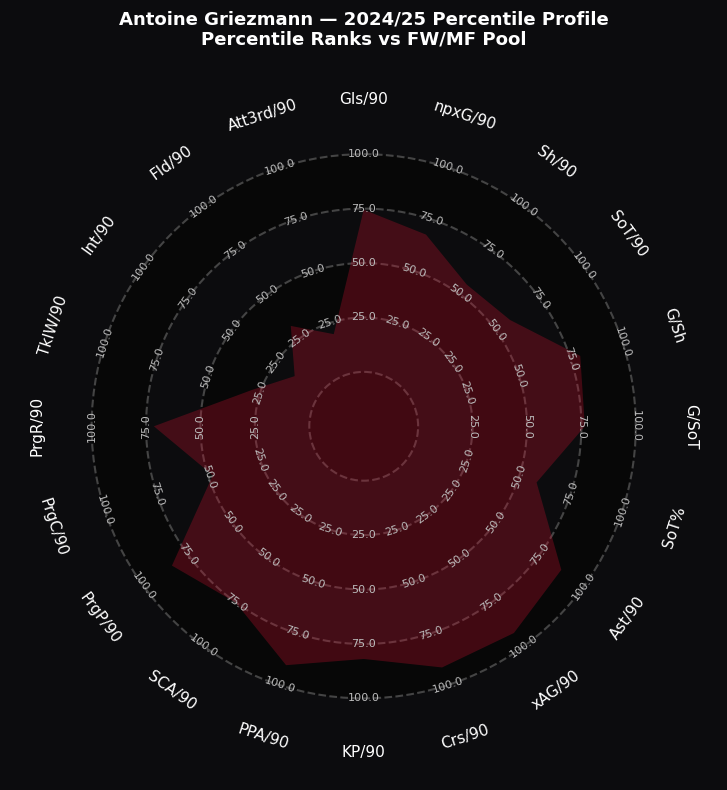

In [127]:
# Percentiles for radar plot
low = [0] * len(radar_features)
high = [100] * len(radar_features)

radar = Radar(radar_features, low, high, num_rings=4, ring_width=1, center_circle_radius=1)

fig, ax = radar.setup_axis(figsize=(8,8))
fig.patch.set_facecolor('#0c0c0e')
ax.set_facecolor('#0c0c0e')

rings_inner = radar.draw_circles(
    ax=ax, 
    facecolor='#070707', 
    edgecolor='#444444',
    linewidth=1.5,
    linestyle='--',
    alpha=1
)

radar_poly, rings_outer, vertices = radar.draw_radar(
    griez_values,
    ax=ax,
    kwargs_radar={'facecolor': '#c8102e', 'alpha': 0.3},
    kwargs_rings={'facecolor': '#1a1a2e', 'alpha': 0}
)

radar.draw_param_labels(ax=ax, fontsize=11, color='white')
radar.draw_range_labels(ax=ax, fontsize=8, color='#BCBCBC')

ax.set_title('Antoine Griezmann — 2024/25 Percentile Profile\nPercentile Ranks vs FW/MF Pool',
             fontsize=13, fontweight='bold', color='white', pad=20)

plt.tight_layout()
plt.savefig('detailed_griezmann_radar_2425.png', dpi=150, bbox_inches='tight', facecolor='#0c0c0e')
plt.show()


In [125]:
gp = griez_percentiles_df.set_index('Metric')['Percentile']

composite_percentiles = {
    'Goal Threat'            : np.mean([gp['Gls/90'], gp['npxG/90'], gp['Sh/90'], gp['SoT/90']]),
    'Finishing Quality'      : np.mean([gp['G/Sh'], gp['G/SoT'], gp['SoT%']]),
    'Chance Creation'        : np.mean([gp['Ast/90'], gp['xAG/90'], gp['KP/90'], gp['PPA/90'], gp['SCA/90'], gp['Crs/90']]),
    'Ball Progression'       : np.mean([gp['PrgP/90'], gp['PrgC/90'], gp['PrgR/90']]),
    'Defensive Contribution' : np.mean([gp['TklW/90'], gp['Int/90'], gp['Att3rd/90'], gp['Fld/90']]),
}

for k, v in composite_percentiles.items():
    print(f"{k}: {v:.1f}")

Goal Threat: 63.9
Finishing Quality: 71.6
Chance Creation: 86.4
Ball Progression: 67.7
Defensive Contribution: 23.7


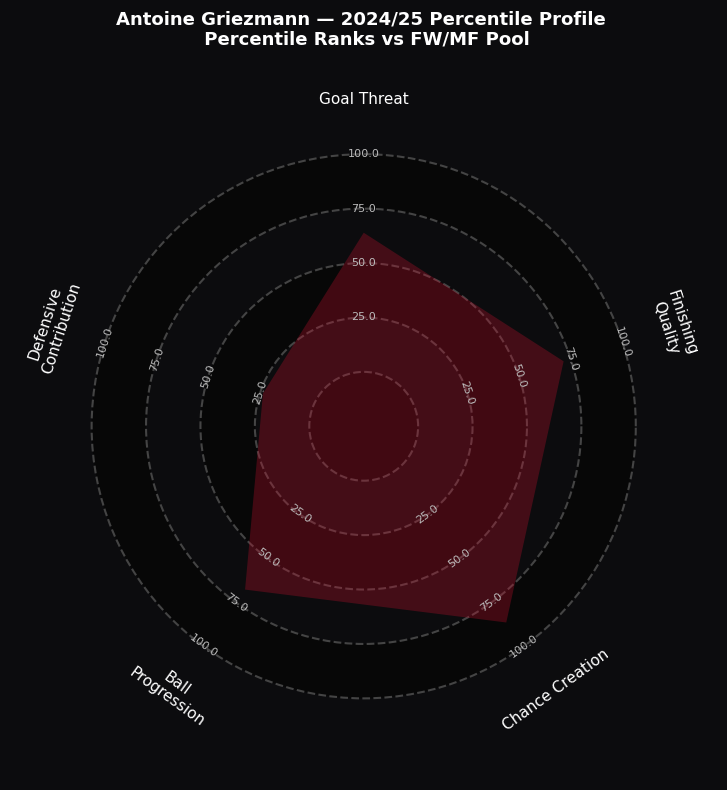

In [126]:
composite_labels = [
    'Goal Threat',
    'Finishing Quality', 
    'Chance Creation',
    'Ball Progression',
    'Defensive Contribution'
]

composite_values = [
    composite_percentiles['Goal Threat'],
    composite_percentiles['Finishing Quality'],
    composite_percentiles['Chance Creation'],
    composite_percentiles['Ball Progression'],
    composite_percentiles['Defensive Contribution']
]

low_c  = [0] * 5
high_c = [100] * 5

radar_composite = Radar(
    composite_labels,
    low_c,
    high_c,
    num_rings=4,
    ring_width=1,
    center_circle_radius=1
)

fig, ax = radar_composite.setup_axis(figsize=(8,8))
fig.patch.set_facecolor('#0c0c0e')
ax.set_facecolor("#0c0c0e") 
rings_inner = radar_composite.draw_circles(
    ax=ax, 
    facecolor="#070707", 
    edgecolor='#444444',
    linewidth=1.5,
    linestyle='--',
    alpha=1
)

radar_poly, rings_outer, vertices = radar_composite.draw_radar(
    composite_values,
    ax=ax,
    kwargs_radar={'facecolor': '#c8102e', 'alpha': 0.3},
    kwargs_rings={'facecolor': '#1a1a2e', 'alpha': 0}
)



radar_composite.draw_param_labels(ax=ax, fontsize=11, color='white')
radar_composite.draw_range_labels(ax=ax, fontsize=8, color="#BCBCBC", alpha=1)

ax.set_title('Antoine Griezmann — 2024/25 Percentile Profile \n Percentile Ranks vs FW/MF Pool',
             fontsize=13, fontweight='bold', color='white', pad=20)

plt.tight_layout()
plt.savefig('griezmann_composite_radar.png', dpi=150, bbox_inches='tight', facecolor='#0c0c0e')
plt.show()


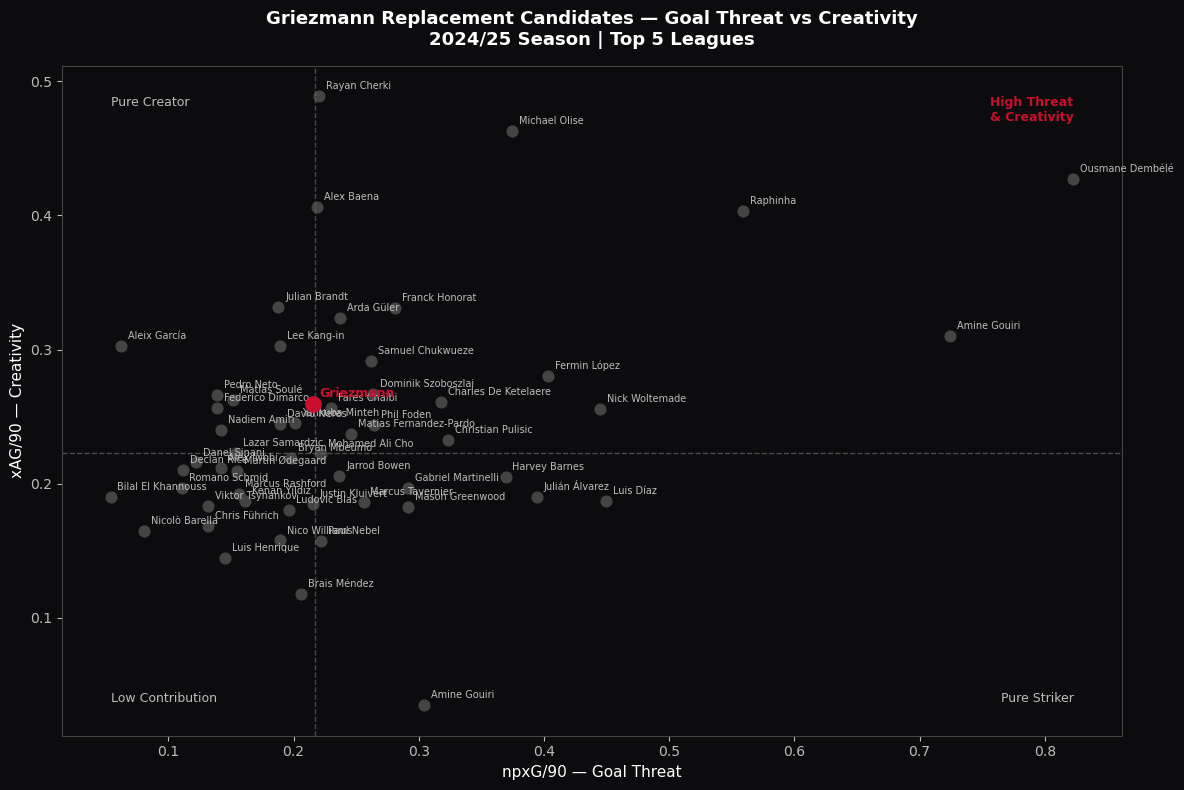

In [128]:
# Scatter plot of Goal Threat vs Creativity
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Pull the overlap players from 24/25 dataset
overlap_names = overlap_final['Player'].tolist()

# Get their stats from 24/25 candidate pool
scatter_df = candidates_2425_p90[candidates_2425_p90['Player'].isin(overlap_names)].copy()

# Median lines - where we draw the quadrant dividers
x_med = scatter_df['npxG/90'].median()
y_med = scatter_df['xAG/90'].median()

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#0c0c0e')
ax.set_facecolor('#0c0c0e')

# Plot all candidates
ax.scatter(scatter_df['npxG/90'], scatter_df['xAG/90'],
           color='#444444', s=60, zorder=2)

# Label each player
for _, row in scatter_df.iterrows():
    ax.annotate(row['Player'],
                (row['npxG/90'], row['xAG/90']),
                fontsize=7, color='#BCBCBC',
                xytext=(5, 5), textcoords='offset points')

# Plot Griezmann separately in red
griez_x = griez_per90_2425['npxG/90'].values[0]
griez_y = griez_per90_2425['xAG/90'].values[0]
ax.scatter(griez_x, griez_y, color='#c8102e', s=120, zorder=3, label='Griezmann')
ax.annotate('Griezmann', (griez_x, griez_y),
            fontsize=9, color='#c8102e', fontweight='bold',
            xytext=(5, 5), textcoords='offset points')

# Quadrant divider lines
ax.axvline(x=x_med, color='#666666', linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(y=y_med, color='#666666', linestyle='--', linewidth=1, alpha=0.7)

# Quadrant labels
ax.text(scatter_df['npxG/90'].max(), scatter_df['xAG/90'].max(),
        'High Threat\n& Creativity', fontsize=9, color='#c8102e',
        ha='right', va='top', fontweight='bold')
ax.text(scatter_df['npxG/90'].min(), scatter_df['xAG/90'].max(),
        'Pure Creator', fontsize=9, color='#BCBCBC',
        ha='left', va='top')
ax.text(scatter_df['npxG/90'].max(), scatter_df['xAG/90'].min(),
        'Pure Striker', fontsize=9, color='#BCBCBC',
        ha='right', va='bottom')
ax.text(scatter_df['npxG/90'].min(), scatter_df['xAG/90'].min(),
        'Low Contribution', fontsize=9, color='#BCBCBC',
        ha='left', va='bottom')

ax.set_xlabel('npxG/90 — Goal Threat', color='white', fontsize=11)
ax.set_ylabel('xAG/90 — Creativity', color='white', fontsize=11)
ax.set_title('Griezmann Replacement Candidates — Goal Threat vs Creativity\n2024/25 Season | Top 5 Leagues',
             fontsize=13, fontweight='bold', color='white', pad=15)

ax.tick_params(colors='#BCBCBC')
ax.spines['bottom'].set_color('#444444')
ax.spines['top'].set_color('#444444')
ax.spines['left'].set_color('#444444')
ax.spines['right'].set_color('#444444')

plt.tight_layout()
#plt.savefig('scatter_threat_creativity.png', dpi=150, bbox_inches='tight', facecolor='#0c0c0e')
plt.show()



In [130]:
# Combine similarity scores with performance metrics from 24/25
scatter2_df = overlap_final[['Player', 'Squad', 'Comp', 'Age', 'similarity_avg']].copy()

# Pull npxG/90 and xAG/90 from 24/25 candidate pool
perf_df = candidates_2425_p90[['Player', 'npxG/90', 'xAG/90']].copy()
perf_df = perf_df.sort_values('npxG/90', ascending=False).drop_duplicates(subset='Player', keep='first')

# Combined performance score
perf_df['performance'] = perf_df['npxG/90'] + perf_df['xAG/90']

# Merge
scatter2_df = scatter2_df.merge(perf_df[['Player', 'performance']], on='Player', how='left')
scatter2_df = scatter2_df.dropna()

print(f"Players: {scatter2_df.shape[0]}")
print(scatter2_df.sort_values('performance', ascending=False).head(10)[['Player', 'similarity_avg', 'performance']].to_string())

griez_performance = griez_per90_2425['npxG/90'].values[0] + griez_per90_2425['xAG/90'].values[0]
griez_similarity = 1.0  # He's the benchmark so similarity to himself is perfect

print(f"Griezmann performance score: {griez_performance:.3f}")
print(f"npxG/90: {griez_per90_2425['npxG/90'].values[0]:.3f}")
print(f"xAG/90: {griez_per90_2425['xAG/90'].values[0]:.3f}")


Players: 53
             Player  similarity_avg  performance
12  Ousmane Dembélé        0.643915     1.250000
31     Amine Gouiri        0.523605     1.034483
10         Raphinha        0.661047     0.961905
18    Michael Olise        0.605157     0.837838
16     Rayan Cherki        0.607976     0.709251
45   Nick Woltemade        0.446511     0.700000
25     Fermin López        0.574297     0.683453
39        Luis Díaz        0.495339     0.636704
17       Alex Baena        0.607733     0.625000
0    Franck Honorat        0.839957     0.612500
Griezmann performance score: 0.474
npxG/90: 0.215
xAG/90: 0.259


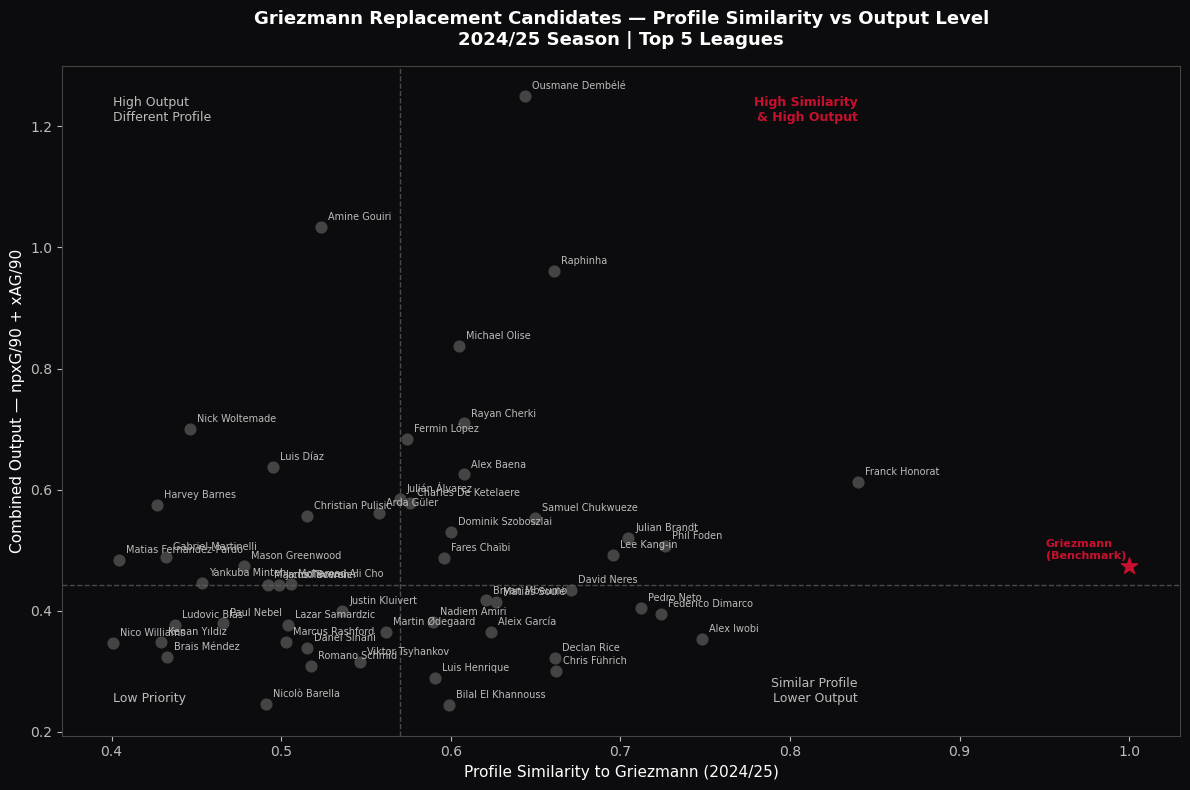

In [131]:
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#0c0c0e')
ax.set_facecolor('#0c0c0e')

# Median lines from candidate pool
x_med = scatter2_df['similarity_avg'].median()
y_med = scatter2_df['performance'].median()

# Plot all 53 candidates
ax.scatter(scatter2_df['similarity_avg'], scatter2_df['performance'],
           color='#444444', s=60, zorder=2)

# Label each player
for _, row in scatter2_df.iterrows():
    ax.annotate(row['Player'],
                (row['similarity_avg'], row['performance']),
                fontsize=7, color='#BCBCBC',
                xytext=(5, 5), textcoords='offset points')

# Plot Griezmann as reference
ax.scatter(1.0, griez_performance,
           color='#c8102e', s=150, zorder=4, marker='*')
ax.annotate('Griezmann\n(Benchmark)',
            (1.0, griez_performance),
            fontsize=8, color='#c8102e', fontweight='bold',
            xytext=(-60, 5), textcoords='offset points')

# Quadrant lines
ax.axvline(x=x_med, color='#666666', linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(y=y_med, color='#666666', linestyle='--', linewidth=1, alpha=0.7)

# Quadrant labels
ax.text(scatter2_df['similarity_avg'].max(), scatter2_df['performance'].max(),
        'High Similarity\n& High Output', fontsize=9, color='#c8102e',
        ha='right', va='top', fontweight='bold')
ax.text(scatter2_df['similarity_avg'].min(), scatter2_df['performance'].max(),
        'High Output\nDifferent Profile', fontsize=9, color='#BCBCBC',
        ha='left', va='top')
ax.text(scatter2_df['similarity_avg'].max(), scatter2_df['performance'].min(),
        'Similar Profile\nLower Output', fontsize=9, color='#BCBCBC',
        ha='right', va='bottom')
ax.text(scatter2_df['similarity_avg'].min(), scatter2_df['performance'].min(),
        'Low Priority', fontsize=9, color='#BCBCBC',
        ha='left', va='bottom')

ax.set_xlabel('Profile Similarity to Griezmann (2024/25)', color='white', fontsize=11)
ax.set_ylabel('Combined Output — npxG/90 + xAG/90', color='white', fontsize=11)
ax.set_title('Griezmann Replacement Candidates — Profile Similarity vs Output Level\n2024/25 Season | Top 5 Leagues',
             fontsize=13, fontweight='bold', color='white', pad=15)

ax.tick_params(colors='#BCBCBC')
ax.spines['bottom'].set_color('#444444')
ax.spines['top'].set_color('#444444')
ax.spines['left'].set_color('#444444')
ax.spines['right'].set_color('#444444')

plt.tight_layout()
plt.savefig('scatter_similarity_output.png', dpi=150, bbox_inches='tight', facecolor='#0c0c0e')
plt.show()

### Updated Pool
Using plots and cosine similarity as tools for the abscense of heatmap data that would make profiling a lot nore accurate a pool of 11 has been determined and replotted to further cutdown


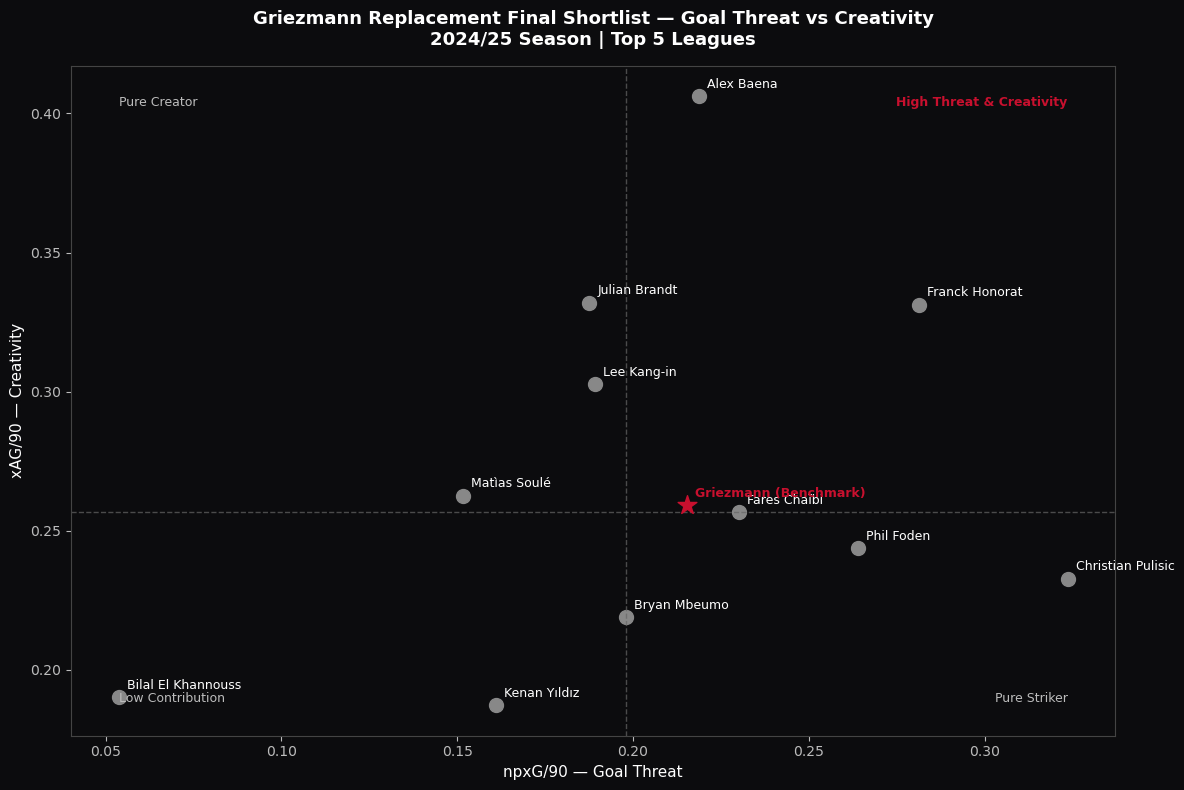

In [132]:
final_shortlist = [
    'Franck Honorat', 'Phil Foden', 'Julian Brandt', 'Lee Kang-in',
    'Matìas Soulé', 'Bryan Mbeumo', 'Alex Baena',
    'Bilal El Khannouss', 'Fares Chaïbi', 'Kenan Yıldız', 'Christian Pulisic'
]

# Filter to shortlist from 24/25 candidates
scatter_final = candidates_2425_p90[candidates_2425_p90['Player'].isin(final_shortlist)].copy()
scatter_final = scatter_final.sort_values('npxG/90', ascending=False).drop_duplicates(subset='Player', keep='first')

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('#0c0c0e')
ax.set_facecolor('#0c0c0e')

x_med = scatter_final['npxG/90'].median()
y_med = scatter_final['xAG/90'].median()

ax.scatter(scatter_final['npxG/90'], scatter_final['xAG/90'],
           color='#888888', s=100, zorder=2)

for _, row in scatter_final.iterrows():
    ax.annotate(row['Player'],
                (row['npxG/90'], row['xAG/90']),
                fontsize=9, color='white',
                xytext=(6, 6), textcoords='offset points')

# Griezmann reference
ax.scatter(griez_per90_2425['npxG/90'].values[0],
           griez_per90_2425['xAG/90'].values[0],
           color='#c8102e', s=200, zorder=4, marker='*')
ax.annotate('Griezmann (Benchmark)',
            (griez_per90_2425['npxG/90'].values[0],
             griez_per90_2425['xAG/90'].values[0]),
            fontsize=9, color='#c8102e', fontweight='bold',
            xytext=(6, 6), textcoords='offset points')

ax.axvline(x=x_med, color='#666666', linestyle='--', linewidth=1, alpha=0.7)
ax.axhline(y=y_med, color='#666666', linestyle='--', linewidth=1, alpha=0.7)

ax.text(scatter_final['npxG/90'].max(), scatter_final['xAG/90'].max(),
        'High Threat & Creativity', fontsize=9, color='#c8102e',
        ha='right', va='top', fontweight='bold')
ax.text(scatter_final['npxG/90'].min(), scatter_final['xAG/90'].max(),
        'Pure Creator', fontsize=9, color='#BCBCBC', ha='left', va='top')
ax.text(scatter_final['npxG/90'].max(), scatter_final['xAG/90'].min(),
        'Pure Striker', fontsize=9, color='#BCBCBC', ha='right', va='bottom')
ax.text(scatter_final['npxG/90'].min(), scatter_final['xAG/90'].min(),
        'Low Contribution', fontsize=9, color='#BCBCBC', ha='left', va='bottom')

ax.set_xlabel('npxG/90 — Goal Threat', color='white', fontsize=11)
ax.set_ylabel('xAG/90 — Creativity', color='white', fontsize=11)
ax.set_title('Griezmann Replacement Final Shortlist — Goal Threat vs Creativity\n2024/25 Season | Top 5 Leagues',
             fontsize=13, fontweight='bold', color='white', pad=15)

ax.tick_params(colors='#BCBCBC')
ax.spines['bottom'].set_color('#444444')
ax.spines['top'].set_color('#444444')
ax.spines['left'].set_color('#444444')
ax.spines['right'].set_color('#444444')

plt.tight_layout()
plt.savefig('scatter_final_shortlist.png', dpi=150, bbox_inches='tight', facecolor='#0c0c0e')
plt.show()

### Reduced Pool Final
Brandt, Kang-In Lee, Honrat, Soule, Chaibi, Foden, Mbeumo

In [133]:
# Save final shortlist
final_shortlist_df = candidates_2425_p90[candidates_2425_p90['Player'].isin([
    'Julian Brandt', 'Lee Kang-in', 'Franck Honorat',
    'Matìas Soulé', 'Fares Chaïbi', 'Phil Foden', 'Bryan Mbeumo', 'Alex Baena'
])].copy()

final_shortlist_df = final_shortlist_df.sort_values('npxG/90', ascending=False).drop_duplicates(subset='Player', keep='first')

final_shortlist_df.to_csv('final_shortlist_2425.csv', index=False)
print(f"Saved {final_shortlist_df.shape[0]} players")
print(final_shortlist_df['Player'].tolist())

Saved 8 players
['Franck Honorat', 'Phil Foden', 'Fares Chaïbi', 'Alex Baena', 'Bryan Mbeumo', 'Lee Kang-in', 'Julian Brandt', 'Matìas Soulé']
